<a href="https://colab.research.google.com/github/heyitsarun/Aero-Gen-Synthetic-Anomaly-Generation-in-Aviation-Communications/blob/main/03_detection_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
print('GPU available:', torch.cuda.is_available())
print('Device name:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')

GPU available: True
Device name: Tesla T4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np

PROJECT_ROOT = '/content/drive/MyDrive/aerogen_project'
DATA_DIR = f'{PROJECT_ROOT}/data'
GEN_DIR = f'{PROJECT_ROOT}/generated'
EVAL_DIR = f'{PROJECT_ROOT}/evaluation'
os.makedirs(EVAL_DIR, exist_ok=True)

# Real, normal ATC transcripts (negative class)
real_df = pd.read_csv(f'{DATA_DIR}/atcosim_enriched.csv')
real_df = real_df[['text']].copy()
real_df['label'] = 0
real_df['generation_method'] = 'real'
real_df['anomaly_type'] = 'none'

# Rule-based synthetic anomalies (positive class)
rule_df = pd.read_csv(f'{GEN_DIR}/synthetic_rule_based.csv')
rule_df = rule_df[['corrupted_text', 'anomaly_type']].copy()
rule_df.columns = ['text', 'anomaly_type']
rule_df['label'] = 1
rule_df['generation_method'] = 'rule_based'

# LLM-generated synthetic anomalies (positive class)
llm_df = pd.read_csv(f'{GEN_DIR}/synthetic_llm_generated.csv')
llm_df = llm_df[['corrupted_text', 'anomaly_type']].copy()
llm_df.columns = ['text', 'anomaly_type']
llm_df['label'] = 1
llm_df['generation_method'] = 'llm_few_shot'

print(f'Real (normal): {len(real_df)}')
print(f'Rule-based synthetic (anomalous): {len(rule_df)}')
print(f'LLM-generated synthetic (anomalous): {len(llm_df)}')

combined_df = pd.concat([real_df, rule_df, llm_df], ignore_index=True)
combined_df = combined_df.dropna(subset=['text']).reset_index(drop=True)
combined_df['text'] = combined_df['text'].astype(str).str.strip()
combined_df = combined_df[combined_df['text'].str.len() > 0].reset_index(drop=True)

print(f'\nTotal combined rows: {len(combined_df)}')
print(combined_df['label'].value_counts())
print(combined_df.groupby(['label','generation_method']).size())

Mounted at /content/drive
Real (normal): 6519
Rule-based synthetic (anomalous): 1312
LLM-generated synthetic (anomalous): 480

Total combined rows: 8311
label
0    6519
1    1792
Name: count, dtype: int64
label  generation_method
0      real                 6519
1      llm_few_shot          480
       rule_based           1312
dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

# Split each source independently (stratified by anomaly_type where relevant),
# so we can later assemble different TRAIN combinations while sharing one fixed TEST set.
real_train, real_test = train_test_split(real_df, test_size=0.2, random_state=42)
rule_train, rule_test = train_test_split(rule_df, test_size=0.2, random_state=42, stratify=rule_df['anomaly_type'])
llm_train, llm_test = train_test_split(llm_df, test_size=0.2, random_state=42, stratify=llm_df['anomaly_type'])

print(f'Real: {len(real_train)} train / {len(real_test)} test')
print(f'Rule-based: {len(rule_train)} train / {len(rule_test)} test')
print(f'LLM: {len(llm_train)} train / {len(llm_test)} test')

# Fixed test set used for ALL model evaluations (fair comparison across configurations)
test_df = pd.concat([real_test, rule_test, llm_test], ignore_index=True)
print(f'\nFixed test set: {len(test_df)} rows, label distribution:')
print(test_df['label'].value_counts())

for path, d in [('real_train', real_train), ('real_test', real_test),
                ('rule_train', rule_train), ('rule_test', rule_test),
                ('llm_train', llm_train), ('llm_test', llm_test),
                ('test_combined', test_df)]:
    d.to_csv(f'{EVAL_DIR}/{path}.csv', index=False)
print('\nSaved all splits to', EVAL_DIR)

Real: 5215 train / 1304 test
Rule-based: 1049 train / 263 test
LLM: 384 train / 96 test

Fixed test set: 1663 rows, label distribution:
label
0    1304
1     359
Name: count, dtype: int64

Saved all splits to /content/drive/MyDrive/aerogen_project/evaluation


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

def build_training_set(*dfs):
    return pd.concat(dfs, ignore_index=True)

def evaluate_baseline(train_df, test_df, label):
    n_classes = train_df['label'].nunique()

    if n_classes < 2:
        # No anomaly examples to learn from — simulate the trivial "always predict normal" baseline
        preds = np.zeros(len(test_df), dtype=int)
        f1 = f1_score(test_df['label'], preds)
        print(f'=== {label} ===')
        print('(Only one class present in training — trivial always-predict-normal baseline)')
        print(classification_report(test_df['label'], preds, target_names=['normal','anomalous'], zero_division=0))
        return f1

    vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
    X_train = vectorizer.fit_transform(train_df['text'])
    X_test = vectorizer.transform(test_df['text'])

    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(X_train, train_df['label'])

    preds = clf.predict(X_test)
    f1 = f1_score(test_df['label'], preds)
    print(f'=== {label} ===')
    print(classification_report(test_df['label'], preds, target_names=['normal','anomalous'], zero_division=0))
    return f1

configs = {
    'Real-only (no anomalies in training)': build_training_set(real_train),
    'Real + Rule-based': build_training_set(real_train, rule_train),
    'Real + LLM-generated': build_training_set(real_train, llm_train),
    'Real + Both': build_training_set(real_train, rule_train, llm_train),
}

baseline_results = {}
for name, tdf in configs.items():
    baseline_results[name] = evaluate_baseline(tdf, test_df, name)
    print()

print('=== F1 Summary ===')
for name, f1 in baseline_results.items():
    print(f'{name}: {f1:.3f}')

=== Real-only (no anomalies in training) ===
(Only one class present in training — trivial always-predict-normal baseline)
              precision    recall  f1-score   support

      normal       0.78      1.00      0.88      1304
   anomalous       0.00      0.00      0.00       359

    accuracy                           0.78      1663
   macro avg       0.39      0.50      0.44      1663
weighted avg       0.61      0.78      0.69      1663


=== Real + Rule-based ===
              precision    recall  f1-score   support

      normal       0.86      0.77      0.81      1304
   anomalous       0.39      0.54      0.46       359

    accuracy                           0.72      1663
   macro avg       0.63      0.66      0.63      1663
weighted avg       0.76      0.72      0.74      1663


=== Real + LLM-generated ===
              precision    recall  f1-score   support

      normal       0.82      0.85      0.84      1304
   anomalous       0.37      0.31      0.34       359

  

In [6]:
baseline_summary = pd.DataFrame([
    {'config': name, 'f1_anomalous': f1, 'model': 'tfidf_logreg'}
    for name, f1 in baseline_results.items()
])
baseline_summary.to_csv(f'{EVAL_DIR}/baseline_results.csv', index=False)
print(baseline_summary)

                                 config  f1_anomalous         model
0  Real-only (no anomalies in training)      0.000000  tfidf_logreg
1                     Real + Rule-based      0.456674  tfidf_logreg
2                  Real + LLM-generated      0.335855  tfidf_logreg
3                           Real + Both      0.456818  tfidf_logreg


In [7]:
!pip install -q transformers datasets accelerate

import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import numpy as np
from sklearn.metrics import f1_score, precision_recall_fscore_support

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

MODEL_NAME = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

Using device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [8]:
EVAL_DIR = f'{PROJECT_ROOT}/evaluation'

real_train = pd.read_csv(f'{EVAL_DIR}/real_train.csv')
rule_train = pd.read_csv(f'{EVAL_DIR}/rule_train.csv')
llm_train = pd.read_csv(f'{EVAL_DIR}/llm_train.csv')
test_df = pd.read_csv(f'{EVAL_DIR}/test_combined.csv')

print(f'real_train: {len(real_train)}, rule_train: {len(rule_train)}, llm_train: {len(llm_train)}, test: {len(test_df)}')

real_train: 5215, rule_train: 1049, llm_train: 384, test: 1663


In [9]:
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=64)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    return {'f1': f1, 'precision': precision, 'recall': recall}

def train_and_evaluate(train_df, test_df, config_name, output_dir):
    train_ds = Dataset.from_pandas(train_df[['text', 'label']].reset_index(drop=True))
    test_ds = Dataset.from_pandas(test_df[['text', 'label']].reset_index(drop=True))

    train_ds = train_ds.map(tokenize_function, batched=True)
    test_ds = test_ds.map(tokenize_function, batched=True)

    model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy='epoch',
        save_strategy='no',
        logging_steps=50,
        report_to='none',
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        compute_metrics=compute_metrics,
    )

    print(f'\n{"="*20} Training: {config_name} {"="*20}')
    trainer.train()
    results = trainer.evaluate()
    print(f'{config_name} final results:', results)
    return results

In [10]:
test_config_df = pd.concat([real_train, llm_train], ignore_index=True)
test_result = train_and_evaluate(test_config_df, test_df, 'TEST RUN: Real + LLM', f'{EVAL_DIR}/test_run')

Map:   0%|          | 0/5599 [00:00<?, ? examples/s]

Map:   0%|          | 0/1663 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



==================== Training: TEST RUN: Real + LLM ====================


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.236754,0.659519,0.328228,0.765306,0.208914
2,0.189843,0.561373,0.305882,0.984848,0.181058
3,0.155374,0.646980,0.332574,0.912500,0.203343


Training Loss,Validation Loss,Epoch,F1,Precision,Recall
0.155374,0.646980,3,0.332574,0.912500,0.203343


TEST RUN: Real + LLM final results: {'eval_loss': 0.6469799876213074, 'eval_f1': 0.3325740318906606, 'eval_precision': 0.9125, 'eval_recall': 0.20334261838440112}


In [11]:
from transformers import Trainer
import torch.nn as nn

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def train_and_evaluate(train_df, test_df, config_name, output_dir):
    train_ds = Dataset.from_pandas(train_df[['text', 'label']].reset_index(drop=True))
    test_ds = Dataset.from_pandas(test_df[['text', 'label']].reset_index(drop=True))
    train_ds = train_ds.map(tokenize_function, batched=True)
    test_ds = test_ds.map(tokenize_function, batched=True)

    model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

    # Class weights inversely proportional to frequency — same principle as class_weight='balanced'
    n_normal = (train_df['label'] == 0).sum()
    n_anomalous = (train_df['label'] == 1).sum()
    total = n_normal + n_anomalous
    class_weights = torch.tensor([total / (2 * n_normal), total / (2 * n_anomalous)], dtype=torch.float)
    print(f'  Class weights (normal, anomalous): {class_weights.tolist()}')

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        greater_is_better=True,
        logging_steps=50,
        report_to='none',
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        compute_metrics=compute_metrics,
        class_weights=class_weights,
    )

    print(f'\n{"="*20} Training: {config_name} {"="*20}')
    trainer.train()
    results = trainer.evaluate()
    print(f'{config_name} final results:', results)
    return results

In [12]:
test_config_df = pd.concat([real_train, llm_train], ignore_index=True)
test_result = train_and_evaluate(test_config_df, test_df, 'TEST RUN: Real + LLM (weighted)', f'{EVAL_DIR}/test_run')

Map:   0%|          | 0/5599 [00:00<?, ? examples/s]

Map:   0%|          | 0/1663 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Class weights (normal, anomalous): [0.5368168950080872, 7.290364742279053]

==================== Training: TEST RUN: Real + LLM (weighted) ====================


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,F1,Precision,Recall
0.576328,0.496184,3,0.380454,0.509346,0.303621


TEST RUN: Real + LLM (weighted) final results: {'eval_loss': 0.49618440866470337, 'eval_f1': 0.38045375218150085, 'eval_precision': 0.5093457943925234, 'eval_recall': 0.30362116991643456}


In [13]:
transformer_results = {}

# Note: "Real-only" can't train a real classifier (single class), so we handle it the same
# trivial way as the baseline — always predict "normal" — for a fair comparison point.
zero_preds = np.zeros(len(test_df), dtype=int)
real_only_f1 = f1_score(test_df['label'], zero_preds)
transformer_results['Real-only (no anomalies in training)'] = {
    'eval_f1': real_only_f1, 'eval_precision': 0.0, 'eval_recall': 0.0
}
print(f"Real-only (trivial baseline): F1={real_only_f1:.3f}\n")

configs = {
    'Real + Rule-based': pd.concat([real_train, rule_train], ignore_index=True),
    'Real + LLM-generated': pd.concat([real_train, llm_train], ignore_index=True),
    'Real + Both': pd.concat([real_train, rule_train, llm_train], ignore_index=True),
}

for name, train_data in configs.items():
    safe_name = name.replace(' ', '_').replace('+', 'plus')
    result = train_and_evaluate(train_data, test_df, name, f'{EVAL_DIR}/{safe_name}')
    transformer_results[name] = result
    print()

print('=== DistilBERT F1 Summary ===')
for name, res in transformer_results.items():
    print(f"{name}: F1={res['eval_f1']:.3f}, Precision={res.get('eval_precision',0):.3f}, Recall={res.get('eval_recall',0):.3f}")

Real-only (trivial baseline): F1=0.000



Map:   0%|          | 0/6264 [00:00<?, ? examples/s]

Map:   0%|          | 0/1663 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,F1,Precision,Recall
0.508353,0.509771,3,0.509246,0.520349,0.498607


Real + Both final results: {'eval_loss': 0.5097705125808716, 'eval_f1': 0.5092460881934566, 'eval_precision': 0.5203488372093024, 'eval_recall': 0.4986072423398329}

=== DistilBERT F1 Summary ===
Real-only (no anomalies in training): F1=0.000, Precision=0.000, Recall=0.000
Real + Rule-based: F1=0.445, Precision=0.379, Recall=0.538
Real + LLM-generated: F1=0.380, Precision=0.509, Recall=0.304
Real + Both: F1=0.509, Precision=0.520, Recall=0.499


In [14]:
transformer_summary = pd.DataFrame([
    {'config': name, 'f1': res['eval_f1'], 'precision': res.get('eval_precision', 0), 'recall': res.get('eval_recall', 0), 'model': 'distilbert'}
    for name, res in transformer_results.items()
])
transformer_summary.to_csv(f'{EVAL_DIR}/transformer_results.csv', index=False)

final_comparison = pd.concat([
    baseline_summary.rename(columns={'f1_anomalous': 'f1'}),
    transformer_summary[['config', 'f1', 'model']]
], ignore_index=True)
final_comparison.to_csv(f'{EVAL_DIR}/final_comparison_table.csv', index=False)
print(final_comparison)

                                 config        f1         model
0  Real-only (no anomalies in training)  0.000000  tfidf_logreg
1                     Real + Rule-based  0.456674  tfidf_logreg
2                  Real + LLM-generated  0.335855  tfidf_logreg
3                           Real + Both  0.456818  tfidf_logreg
4  Real-only (no anomalies in training)  0.000000    distilbert
5                     Real + Rule-based  0.444700    distilbert
6                  Real + LLM-generated  0.380454    distilbert
7                           Real + Both  0.509246    distilbert


In [15]:
def train_and_evaluate_v2(train_df, test_df, config_name, output_dir):
    train_ds = Dataset.from_pandas(train_df[['text', 'label']].reset_index(drop=True))
    test_ds = Dataset.from_pandas(test_df[['text', 'label']].reset_index(drop=True))
    train_ds = train_ds.map(tokenize_function, batched=True)
    test_ds = test_ds.map(tokenize_function, batched=True)

    model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

    n_normal = (train_df['label'] == 0).sum()
    n_anomalous = (train_df['label'] == 1).sum()
    total = n_normal + n_anomalous
    class_weights = torch.tensor([total / (2 * n_normal), total / (2 * n_anomalous)], dtype=torch.float)

    args = TrainingArguments(
        output_dir=output_dir, num_train_epochs=3,
        per_device_train_batch_size=16, per_device_eval_batch_size=32,
        eval_strategy='epoch', save_strategy='epoch',
        load_best_model_at_end=True, metric_for_best_model='f1', greater_is_better=True,
        logging_steps=50, report_to='none',
    )

    trainer = WeightedTrainer(
        model=model, args=args, train_dataset=train_ds, eval_dataset=test_ds,
        compute_metrics=compute_metrics, class_weights=class_weights,
    )
    trainer.train()
    results = trainer.evaluate()
    return results, trainer, test_ds

best_train_df = pd.concat([real_train, rule_train, llm_train], ignore_index=True)
best_results, best_trainer, best_test_ds = train_and_evaluate_v2(
    best_train_df, test_df, 'Real + Both (for analysis)', f'{EVAL_DIR}/best_model_analysis'
)
print(best_results)

Map:   0%|          | 0/6648 [00:00<?, ? examples/s]

Map:   0%|          | 0/1663 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.612780,0.549798,0.450331,0.429293,0.473538
2,0.574723,0.522882,0.477124,0.577075,0.406685
3,0.508353,0.509771,0.509246,0.520349,0.498607


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,F1,Precision,Recall
0.508353,0.509771,3,0.509246,0.520349,0.498607


{'eval_loss': 0.5097705125808716, 'eval_f1': 0.5092460881934566, 'eval_precision': 0.5203488372093024, 'eval_recall': 0.4986072423398329}


=== Recall by anomaly type (Real + Both, DistilBERT) ===
                                         recall  n_test_examples
anomaly_type                                                    
no_callsign_used                       0.971014               69
readback_error_squawk_code             0.941176               17
readback_error_unclassified            0.750000                4
readback_error_heading                 0.666667               21
readback_error_frequency               0.448276               58
missing_similarity_warning             0.416667               12
readback_error_altitude                0.406780               59
callsign_confusion_different_operator  0.268657               67
callsign_confusion_same_company        0.115385               52


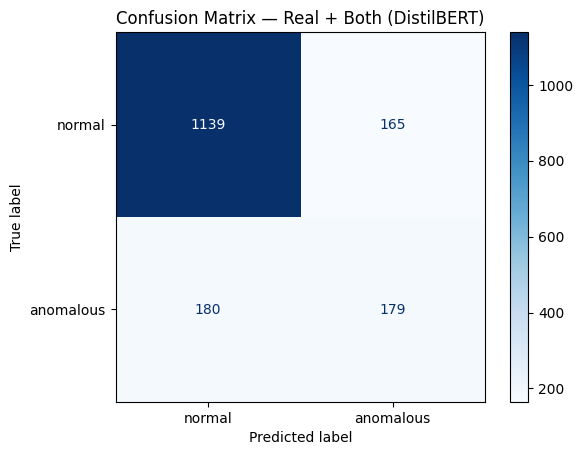


=== 180 False Negatives (missed anomalies) — sample ===
  [readback_error_altitude] delta india mike mike echo f  climb flight level three four zero
  [callsign_confusion_same_company] speed bird one two nine contact rhein one two seven three seven tschuss
  [callsign_confusion_same_company] nato one zero disregard is identified
  [missing_similarity_warning] lufthansa five three zero six contact rhein radar one three two decimal four
  [callsign_confusion_different_operator] onur air nine eight nine turn right by ten degrees

=== 165 False Positives (normal flagged as anomalous) — sample ===
  merair six nine five two good afternoon continue climb to level two six zero
  good morning turkish nine two five squawk one zero zero five and proceed direct hochwald morok
  air malta one zero four good afternoon squawk five seven three zero
  foxtrot sierra india climb flight level three three zero set course trasadingen
  maintain level three hundred expect higher with zurich


In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions on the full test set
preds_output = best_trainer.predict(best_test_ds)
pred_labels = np.argmax(preds_output.predictions, axis=-1)

results_df = test_df.copy().reset_index(drop=True)
results_df['predicted'] = pred_labels
results_df['correct'] = results_df['label'] == results_df['predicted']

# --- 1. Per-anomaly-type recall breakdown ---
print("=== Recall by anomaly type (Real + Both, DistilBERT) ===")
anomaly_only = results_df[results_df['label'] == 1]
type_recall = anomaly_only.groupby('anomaly_type')['correct'].agg(['mean', 'count'])
type_recall.columns = ['recall', 'n_test_examples']
print(type_recall.sort_values('recall', ascending=False))

# --- 2. Confusion matrix ---
cm = confusion_matrix(results_df['label'], results_df['predicted'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['normal', 'anomalous'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Real + Both (DistilBERT)')
plt.savefig(f'{EVAL_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 3. Qualitative error examples ---
false_negatives = results_df[(results_df['label']==1) & (results_df['predicted']==0)]
false_positives = results_df[(results_df['label']==0) & (results_df['predicted']==1)]

print(f"\n=== {len(false_negatives)} False Negatives (missed anomalies) — sample ===")
for _, r in false_negatives.sample(min(5, len(false_negatives)), random_state=1).iterrows():
    print(f"  [{r['anomaly_type']}] {r['text']}")

print(f"\n=== {len(false_positives)} False Positives (normal flagged as anomalous) — sample ===")
for _, r in false_positives.sample(min(5, len(false_positives)), random_state=1).iterrows():
    print(f"  {r['text']}")

results_df.to_csv(f'{EVAL_DIR}/detailed_predictions.csv', index=False)

In [17]:
type_recall.to_csv(f'{EVAL_DIR}/per_type_recall.csv')

In [18]:
# Hand-built validation set: real ASRS incident patterns, manually written in ATCOSIM-style
# phrasing, NOT generated by either synthetic pipeline. Tests generalization beyond the
# model's own training distribution.

asrs_grounded_examples = [
    # Callsign confusion — same company, similar flight number
    {"text": "lufthansa two three one one climb flight level three three zero", "label": 1, "anomaly_type": "callsign_confusion_same_company", "note": "swap target: lufthansa 2311 vs 2331 same-day ops"},
    {"text": "speedbird four one six contact london one two six decimal seven", "label": 1, "anomaly_type": "callsign_confusion_same_company", "note": "similar BA flight number pattern"},
    {"text": "swiss one eight two five descend flight level two four zero", "label": 1, "anomaly_type": "callsign_confusion_same_company", "note": "same-carrier confusion"},

    # Callsign confusion — different operator, similar sound
    {"text": "delta eight three two turn left heading zero niner zero", "label": 1, "anomaly_type": "callsign_confusion_different_operator", "note": "delta/deutsche similar phonetics"},
    {"text": "koreanair five four zero climb and maintain one zero thousand", "label": 1, "anomaly_type": "callsign_confusion_different_operator", "note": "different operator, similar cadence"},
    {"text": "airfrance three two nine contact approach one two zero decimal five", "label": 1, "anomaly_type": "callsign_confusion_different_operator", "note": "cross-operator confusion"},

    # No callsign used
    {"text": "descend and maintain flight level two two zero", "label": 1, "anomaly_type": "no_callsign_used", "note": "instruction with no addressee"},
    {"text": "turn right heading three one zero contact departure", "label": 1, "anomaly_type": "no_callsign_used", "note": "no callsign stated"},
    {"text": "cleared for takeoff runway two seven left", "label": 1, "anomaly_type": "no_callsign_used", "note": "no callsign stated"},

    # Missing similarity warning (instruction correct in isolation, but ATC failed to flag known clash)
    {"text": "united four five six contact center one three four decimal two", "label": 1, "anomaly_type": "missing_similarity_warning", "note": "known similar callsign pair on freq, no caution issued"},
    {"text": "cactus seven eight nine climb flight level three one zero", "label": 1, "anomaly_type": "missing_similarity_warning", "note": "no similarity caution given"},

    # Readback errors — altitude/frequency/heading/squawk
    {"text": "klm eight eight one descend to flight level one nine zero", "label": 1, "anomaly_type": "readback_error_altitude", "note": "crew read back 190 instead of assigned 290"},
    {"text": "iberia six one four contact approach one one eight decimal three", "label": 1, "anomaly_type": "readback_error_frequency", "note": "one digit transposed on readback"},
    {"text": "tap two five zero turn left heading zero four zero", "label": 1, "anomaly_type": "readback_error_heading", "note": "heading misheard by 40 degrees"},
    {"text": "finnair two two six squawk four six zero one", "label": 1, "anomaly_type": "readback_error_squawk_code", "note": "squawk digit swapped"},

    # Normal / correct transmissions (label 0) — same domains, no anomaly
    {"text": "ryanair four four two contact tower one one eight decimal one", "label": 0, "anomaly_type": "none", "note": "normal handoff"},
    {"text": "vueling seven one three climb flight level two eight zero", "label": 0, "anomaly_type": "none", "note": "normal climb clearance"},
    {"text": "easyjet three three one turn right heading two seven zero", "label": 0, "anomaly_type": "none", "note": "normal vector"},
    {"text": "norwegian six one two descend and maintain one zero thousand feet", "label": 0, "anomaly_type": "none", "note": "normal descent"},
    {"text": "wizzair eight four five squawk two one zero five identified", "label": 0, "anomaly_type": "none", "note": "normal squawk assignment"},
    {"text": "aerlingus one zero six contact ground one two one decimal eight", "label": 0, "anomaly_type": "none", "note": "normal ground handoff"},
    {"text": "condor five five zero maintain flight level three five zero", "label": 0, "anomaly_type": "none", "note": "normal maintain instruction"},
    {"text": "pegasus two two four cleared ils approach runway two four", "label": 0, "anomaly_type": "none", "note": "normal approach clearance"},
    {"text": "austrian nine one three reduce speed two five zero knots", "label": 0, "anomaly_type": "none", "note": "normal speed instruction"},
    {"text": "tui airways six six one report established localizer", "label": 0, "anomaly_type": "none", "note": "normal report request"},
]

asrs_val_df = pd.DataFrame(asrs_grounded_examples)
asrs_val_df.to_csv(f'{EVAL_DIR}/asrs_grounded_validation.csv', index=False)
print(f'Built {len(asrs_val_df)} hand-crafted validation examples')
print(asrs_val_df['label'].value_counts())
print(asrs_val_df[asrs_val_df['label']==1]['anomaly_type'].value_counts())

Built 25 hand-crafted validation examples
label
1    15
0    10
Name: count, dtype: int64
anomaly_type
callsign_confusion_same_company          3
callsign_confusion_different_operator    3
no_callsign_used                         3
missing_similarity_warning               2
readback_error_altitude                  1
readback_error_frequency                 1
readback_error_heading                   1
readback_error_squawk_code               1
Name: count, dtype: int64


In [19]:
asrs_ds = Dataset.from_pandas(asrs_val_df[['text', 'label']].reset_index(drop=True))
asrs_ds = asrs_ds.map(tokenize_function, batched=True)

asrs_preds = best_trainer.predict(asrs_ds)
asrs_pred_labels = np.argmax(asrs_preds.predictions, axis=-1)

asrs_val_df['predicted'] = asrs_pred_labels
asrs_val_df['correct'] = asrs_val_df['label'] == asrs_val_df['predicted']

from sklearn.metrics import f1_score as f1s, precision_score, recall_score
print(f"ASRS-grounded validation F1: {f1s(asrs_val_df['label'], asrs_pred_labels):.3f}")
print(f"Precision: {precision_score(asrs_val_df['label'], asrs_pred_labels):.3f}")
print(f"Recall: {recall_score(asrs_val_df['label'], asrs_pred_labels):.3f}")
print()
print(asrs_val_df[['text','anomaly_type','label','predicted','correct']])

Map:   0%|          | 0/25 [00:00<?, ? examples/s]

ASRS-grounded validation F1: 0.552
Precision: 0.571
Recall: 0.533

                                                 text  \
0   lufthansa two three one one climb flight level...   
1   speedbird four one six contact london one two ...   
2   swiss one eight two five descend flight level ...   
3   delta eight three two turn left heading zero n...   
4   koreanair five four zero climb and maintain on...   
5   airfrance three two nine contact approach one ...   
6      descend and maintain flight level two two zero   
7   turn right heading three one zero contact depa...   
8           cleared for takeoff runway two seven left   
9   united four five six contact center one three ...   
10  cactus seven eight nine climb flight level thr...   
11  klm eight eight one descend to flight level on...   
12  iberia six one four contact approach one one e...   
13  tap two five zero turn left heading zero four ...   
14       finnair two two six squawk four six zero one   
15  ryanair four four

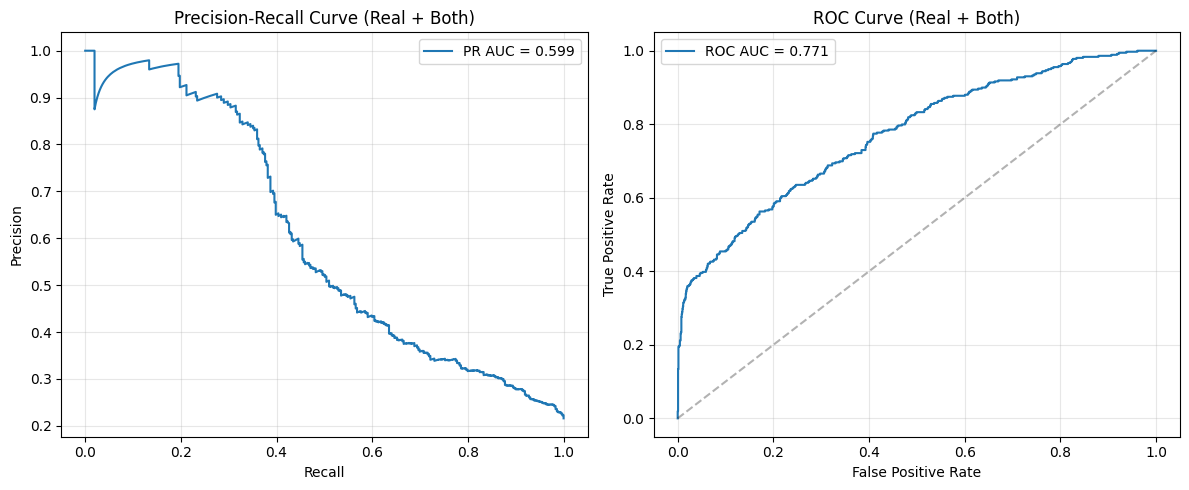

In [20]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc, PrecisionRecallDisplay, RocCurveDisplay
import torch.nn.functional as F

logits = torch.tensor(preds_output.predictions)
probs = F.softmax(logits, dim=1)[:, 1].numpy()  # probability of "anomalous"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

precision, recall, _ = precision_recall_curve(results_df['label'], probs)
pr_auc = auc(recall, precision)
axes[0].plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (Real + Both)')
axes[0].legend(); axes[0].grid(alpha=0.3)

fpr, tpr, _ = roc_curve(results_df['label'], probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Real + Both)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{EVAL_DIR}/pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
final_table = final_comparison.pivot_table(index='config', columns='model', values='f1').reset_index()
final_table['config'] = pd.Categorical(final_table['config'], categories=[
    'Real-only (no anomalies in training)', 'Real + Rule-based', 'Real + LLM-generated', 'Real + Both'
], ordered=True)
final_table = final_table.sort_values('config')
print(final_table.to_string(index=False))
final_table.to_csv(f'{EVAL_DIR}/final_comparison_table_pivoted.csv', index=False)

                              config  distilbert  tfidf_logreg
Real-only (no anomalies in training)    0.000000      0.000000
                   Real + Rule-based    0.444700      0.456674
                Real + LLM-generated    0.380454      0.335855
                         Real + Both    0.509246      0.456818


In [23]:
atcosim_full_text = ' '.join(real_df['text'].str.lower())
test_airlines = ['ryanair', 'vueling', 'easyjet', 'wizzair', 'aerlingus', 'pegasus', 'norwegian', 'condor', 'austrian', 'tui airways']

for a in test_airlines:
    present = a in atcosim_full_text
    print(f'{a}: {"in training vocab" if present else "NOT in training vocab"}')

ryanair: NOT in training vocab
vueling: NOT in training vocab
easyjet: NOT in training vocab
wizzair: NOT in training vocab
aerlingus: NOT in training vocab
pegasus: NOT in training vocab
norwegian: NOT in training vocab
condor: in training vocab
austrian: in training vocab
tui airways: NOT in training vocab


In [24]:
vocab_check_results = pd.DataFrame({
    'airline': test_airlines,
    'in_training_vocab': [a in atcosim_full_text for a in test_airlines],
})
vocab_check_results = vocab_check_results.merge(
    asrs_val_df[asrs_val_df['label']==0][['text','predicted']].reset_index(drop=True),
    left_index=True, right_index=True, how='left'
)
vocab_check_results.to_csv(f'{EVAL_DIR}/airline_vocab_bias_analysis.csv', index=False)
print(vocab_check_results)

       airline  in_training_vocab  \
0      ryanair              False   
1      vueling              False   
2      easyjet              False   
3      wizzair              False   
4    aerlingus              False   
5      pegasus              False   
6    norwegian              False   
7       condor               True   
8     austrian               True   
9  tui airways              False   

                                                text  predicted  
0  ryanair four four two contact tower one one ei...          1  
1  vueling seven one three climb flight level two...          1  
2  easyjet three three one turn right heading two...          1  
3  norwegian six one two descend and maintain one...          0  
4  wizzair eight four five squawk two one zero fi...          1  
5  aerlingus one zero six contact ground one two ...          1  
6  condor five five zero maintain flight level th...          0  
7  pegasus two two four cleared ils approach runw...          1 